# Facial Expression Recognition and Continuous Affect Estimation
## Haroon 21i-1763

## Dataset Preparation
- Loading image paths, annotations, and preprocessing steps (resize, normalization, landmarks).


In [2]:
# Paths to images and annotations
img_path = "/kaggle/input/facial-data/Dataset/images"
ann_path = "/kaggle/input/facial-data/Dataset/annotations"

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import timm

import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## DataLoader Setup and Model: ResNet18 Training
- Creating PyTorch Dataset and DataLoader objects for train, validation, and test splits.
- Initializing ResNet18 with pretrained ImageNet weights and adapting final layers.


In [3]:
# ==============================
# 1. Imports
# ==============================
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from tqdm import tqdm

# ==============================
# 2. Dataset Class
# ==============================
class FacialExpressionDataset(Dataset):
    def __init__(self, img_path, ann_path, transform=None):
        self.img_path = img_path
        self.ann_path = ann_path
        self.transform = transform

        # only use indices that have _exp.npy
        all_files = [f for f in os.listdir(ann_path) if f.endswith("_exp.npy")]
        self.indices = [f.split("_")[0] for f in all_files]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx = self.indices[idx]

        img_file = os.path.join(self.img_path, f"{img_idx}.jpg")
        exp_file = os.path.join(self.ann_path, f"{img_idx}_exp.npy")
        val_file = os.path.join(self.ann_path, f"{img_idx}_val.npy")
        aro_file = os.path.join(self.ann_path, f"{img_idx}_aro.npy")

        # image
        img = Image.open(img_file).convert("RGB")
        if self.transform:
            img = self.transform(img)

        # safe label loading
        exp = int(np.load(exp_file, allow_pickle=True).item())
        val = float(np.load(val_file, allow_pickle=True).item())
        aro = float(np.load(aro_file, allow_pickle=True).item())

        return img, torch.tensor([exp, val, aro], dtype=torch.float32)

# ==============================
# 3. Paths
# ==============================
img_path = "/kaggle/input/facial-data/Dataset/images"
ann_path = "/kaggle/input/facial-data/Dataset/annotations"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = FacialExpressionDataset(img_path, ann_path, transform=transform)
print(f"Total samples: {len(dataset)}")

# ==============================
# 4. Split into Train/Val
# ==============================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# ==============================
# 5. Model (ResNet18 baseline)
# ==============================
class FacialExpressionModel(nn.Module):
    def __init__(self, num_classes=8):
        super(FacialExpressionModel, self).__init__()
        base = models.resnet18(weights=None)
        in_features = base.fc.in_features
        base.fc = nn.Identity()
        self.feature_extractor = base

        self.fc_exp = nn.Linear(in_features, num_classes)  # classification
        self.fc_val = nn.Linear(in_features, 1)            # regression
        self.fc_aro = nn.Linear(in_features, 1)            # regression

    def forward(self, x):
        feats = self.feature_extractor(x)
        exp_logits = self.fc_exp(feats)
        val_pred = self.fc_val(feats)
        aro_pred = self.fc_aro(feats)
        return exp_logits, val_pred, aro_pred

# ==============================
# 6. Training Loop with Saving
# ==============================
def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4, save_path="resnet18_trained.pth"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion_cls = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long()
            val_labels = labels[:,1].unsqueeze(1)
            aro_labels = labels[:,2].unsqueeze(1)

            optimizer.zero_grad()
            exp_logits, val_pred, aro_pred = model(imgs)

            loss_cls = criterion_cls(exp_logits, exp_labels)
            loss_val = criterion_reg(val_pred, val_labels)
            loss_aro = criterion_reg(aro_pred, aro_labels)
            loss = loss_cls + loss_val + loss_aro

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            total_correct += (exp_logits.argmax(1) == exp_labels).sum().item()
            total_samples += imgs.size(0)
            loop.set_postfix(loss=loss.item())

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        # validation
        model.eval()
        val_loss, val_correct, val_samples = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                exp_labels = labels[:,0].long()
                val_labels = labels[:,1].unsqueeze(1)
                aro_labels = labels[:,2].unsqueeze(1)

                exp_logits, val_pred, aro_pred = model(imgs)

                loss_cls = criterion_cls(exp_logits, exp_labels)
                loss_val = criterion_reg(val_pred, val_labels)
                loss_aro = criterion_reg(aro_pred, aro_labels)
                loss = loss_cls + loss_val + loss_aro

                val_loss += loss.item() * imgs.size(0)
                val_correct += (exp_logits.argmax(1) == exp_labels).sum().item()
                val_samples += imgs.size(0)

        val_loss /= val_samples
        val_acc = val_correct / val_samples

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Save model after training
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

# ==============================
# 7. Run Training
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FacialExpressionModel(num_classes=8)
train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-4)

# ==============================
# 8. Evaluation Only (Load Saved Model)
# ==============================
def evaluate_model(model, val_loader, device, load_path="resnet18_trained.pth"):
    model.load_state_dict(torch.load(load_path))
    model.to(device)
    model.eval()
    criterion_cls = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()

    total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long()
            val_labels = labels[:,1].unsqueeze(1)
            aro_labels = labels[:,2].unsqueeze(1)

            exp_logits, val_pred, aro_pred = model(imgs)

            loss_cls = criterion_cls(exp_logits, exp_labels)
            loss_val = criterion_reg(val_pred, val_labels)
            loss_aro = criterion_reg(aro_pred, aro_labels)
            loss = loss_cls + loss_val + loss_aro

            total_loss += loss.item() * imgs.size(0)
            total_correct += (exp_logits.argmax(1) == exp_labels).sum().item()
            total_samples += imgs.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    print(f"Validation Loss={avg_loss:.4f}, Validation Accuracy={accuracy:.4f}")

# Example: evaluate saved model
evaluate_model(FacialExpressionModel(num_classes=8), val_loader, device)


Total samples: 3999
Train samples: 3199, Val samples: 800
Using device: cuda


Epoch 1/20: Train Loss=2.4663, Train Acc=0.1560, Val Loss=2.6110, Val Acc=0.1600


Epoch 2/20: Train Loss=2.2941, Train Acc=0.2535, Val Loss=2.5727, Val Acc=0.1925


Epoch 3/20: Train Loss=2.0256, Train Acc=0.3832, Val Loss=2.6445, Val Acc=0.1837


Epoch 4/20: Train Loss=1.5183, Train Acc=0.5658, Val Loss=3.6654, Val Acc=0.1388


...

Epoch 16/20: Train Loss=0.0461, Train Acc=0.9984, Val Loss=3.1700, Val Acc=0.2225


Epoch 17/20: Train Loss=0.0456, Train Acc=0.9978, Val Loss=3.0998, Val Acc=0.2325


Epoch 18/20: Train Loss=0.0416, Train Acc=0.9991, Val Loss=3.0972, Val Acc=0.2425


Epoch 19/20: Train Loss=0.0375, Train Acc=0.9991, Val Loss=3.2958, Val Acc=0.2162


Epoch 20/20: Train Loss=0.0625, Train Acc=0.9931, Val Loss=3.8811, Val Acc=0.1925
Model saved to resnet18_trained.pth
Validation Loss=3.8811, Validation Accuracy=0.1925


## Model: ResNet18 Evaluations 

In [4]:
# ==============================
# 8. Evaluation Metrics
# ==============================
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from scipy.stats import pearsonr
import numpy as np

def krippendorffs_alpha(labels, predictions):
    """
    Compute Krippendorff's alpha for nominal/categorical data
    """
    labels = np.array(labels)
    predictions = np.array(predictions)
    data = np.vstack([labels, predictions])
    n_items = labels.shape[0]
    n_raters = 2
    coincidence = np.zeros((np.max(data)+1, np.max(data)+1))
    
    for i in range(n_items):
        coincidence[data[0,i], data[1,i]] += 1
        coincidence[data[1,i], data[0,i]] += 1

    coincidence = coincidence / (n_items * n_raters)
    expected = np.outer(coincidence.sum(axis=0), coincidence.sum(axis=1))
    observed = np.trace(coincidence)
    expected = np.trace(expected)
    alpha = (observed - expected) / (1 - expected) if (1 - expected) != 0 else 0.0
    return alpha

def concordance_correlation_coefficient(y_true, y_pred):
    """Computes CCC for continuous regression metrics"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.mean((y_true - mean_true)*(y_pred - mean_pred))
    ccc = 2*covariance / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)
    return ccc

def sign_agreement(y_true, y_pred):
    """Sign Agreement Metric (SAGR)"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def evaluate_model(model, data_loader, device):
    model.eval()
    all_exp, all_val, all_aro = [], [], []
    all_exp_pred, all_val_pred, all_aro_pred = [], [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long()
            val_labels = labels[:,1].cpu().numpy()
            aro_labels = labels[:,2].cpu().numpy()

            exp_logits, val_pred, aro_pred = model(imgs)
            exp_pred = exp_logits.argmax(1).cpu().numpy()
            val_pred = val_pred.squeeze(1).cpu().numpy()
            aro_pred = aro_pred.squeeze(1).cpu().numpy()

            all_exp.extend(exp_labels.cpu().numpy())
            all_val.extend(val_labels)
            all_aro.extend(aro_labels)
            all_exp_pred.extend(exp_pred)
            all_val_pred.extend(val_pred)
            all_aro_pred.extend(aro_pred)

    # --- Categorical metrics (Expression) ---
    acc = accuracy_score(all_exp, all_exp_pred)
    f1 = f1_score(all_exp, all_exp_pred, average='weighted')
    kappa = cohen_kappa_score(all_exp, all_exp_pred)
    kripp_alpha = krippendorffs_alpha(all_exp, all_exp_pred)

    # AUC & AUC-PR (one-hot needed)
    from sklearn.preprocessing import label_binarize
    all_exp_onehot = label_binarize(all_exp, classes=list(range(max(all_exp)+1)))
    all_exp_pred_onehot = label_binarize(all_exp_pred, classes=list(range(max(all_exp)+1)))
    try:
        auc = roc_auc_score(all_exp_onehot, all_exp_pred_onehot, average='macro', multi_class='ovo')
    except:
        auc = np.nan
    try:
        auc_pr = average_precision_score(all_exp_onehot, all_exp_pred_onehot, average='macro')
    except:
        auc_pr = np.nan

    # --- Continuous metrics (Valence & Arousal) ---
    metrics_cont = {}
    for name, true, pred in zip(["Valence", "Arousal"], [all_val, all_aro], [all_val_pred, all_aro_pred]):
        true = np.array(true)
        pred = np.array(pred)
        rmse = np.sqrt(np.mean((true - pred)**2))
        corr, _ = pearsonr(true, pred)
        sagr = sign_agreement(true, pred)
        ccc = concordance_correlation_coefficient(true, pred)
        metrics_cont[name] = {"RMSE": rmse, "CORR": corr, "SAGR": sagr, "CCC": ccc}

    # Print
    print("=== Categorical (Expression) Metrics ===")
    print(f"Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, Cohen's Kappa: {kappa:.4f}, Krippendorff's Alpha: {kripp_alpha:.4f}")
    print(f"AUC: {auc:.4f}, AUC-PR: {auc_pr:.4f}\n")

    print("=== Continuous Metrics ===")
    for key, vals in metrics_cont.items():
        print(f"{key}: RMSE={vals['RMSE']:.4f}, CORR={vals['CORR']:.4f}, SAGR={vals['SAGR']:.4f}, CCC={vals['CCC']:.4f}")

# ==============================
# 9. Run Evaluation
# ==============================
evaluate_model(model, val_loader, device)

=== Categorical (Expression) Metrics ===
Accuracy: 0.1925, F1-Score: 0.1725, Cohen's Kappa: 0.0813, Krippendorff's Alpha: 0.0468
AUC: 0.5419, AUC-PR: 0.1442

=== Continuous Metrics ===
Valence: RMSE=0.4642, CORR=0.2603, SAGR=0.6950, CCC=0.2096
Arousal: RMSE=0.4018, CORR=0.1626, SAGR=0.7562, CCC=0.1152


## Training Model: VGG16
- Initializing VGG16 architecture and customizing classifier head for affective tasks.

## Training Model: EfficientNetB0
- Using EfficientNetB0 for lightweight yet efficient feature extraction and classification.

## Training Model: MobileNetV2
- Defining MobileNetV2 as a baseline for low-parameter affect recognition.

## Training Model: DenseNet121
- Setting up DenseNet121 with pretrained weights and modifying output layers.


In [5]:
# ==============================
# 1. Imports
# ==============================
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from tqdm import tqdm
import random

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ==============================
# 2. Dataset Class
# ==============================
class FacialExpressionDataset(Dataset):
    def __init__(self, img_path, ann_path, transform=None):
        self.img_path = img_path
        self.ann_path = ann_path
        self.transform = transform

        all_files = [f for f in os.listdir(ann_path) if f.endswith("_exp.npy")]
        self.indices = [f.split("_")[0] for f in all_files]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx = self.indices[idx]

        img_file = os.path.join(self.img_path, f"{img_idx}.jpg")
        exp_file = os.path.join(self.ann_path, f"{img_idx}_exp.npy")
        val_file = os.path.join(self.ann_path, f"{img_idx}_val.npy")
        aro_file = os.path.join(self.ann_path, f"{img_idx}_aro.npy")

        img = Image.open(img_file).convert("RGB")
        if self.transform:
            img = self.transform(img)

        exp = int(np.load(exp_file, allow_pickle=True).item())
        val = float(np.load(val_file, allow_pickle=True).item())
        aro = float(np.load(aro_file, allow_pickle=True).item())

        return img, torch.tensor([exp, val, aro], dtype=torch.float32)

# ==============================
# 3. Paths & Transforms
# ==============================
img_path = "/kaggle/input/facial-data/Dataset/images"
ann_path = "/kaggle/input/facial-data/Dataset/annotations"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = FacialExpressionDataset(img_path, ann_path, transform=transform)
print(f"Total samples: {len(dataset)}")

# ==============================
# 4. Train/Validation Split
# ==============================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# ==============================
# 5. Multi-Backbone Model
# ==============================
class FacialExpressionModel(nn.Module):
    def __init__(self, backbone_name='vgg16', num_classes=8, pretrained=False):
        super(FacialExpressionModel, self).__init__()

        if backbone_name == 'vgg16':
            self.backbone = models.vgg16(weights=None if not pretrained else models.VGG16_Weights.DEFAULT)
            # Remove classifier and keep features only
            self.features = self.backbone.features
            self.avgpool = self.backbone.avgpool
            in_features = 25088  # VGG16 flattened feature size
        elif backbone_name == 'densenet121':
            self.backbone = models.densenet121(weights=None if not pretrained else models.DenseNet121_Weights.DEFAULT)
            self.features = self.backbone.features
            in_features = self.backbone.classifier.in_features
        elif backbone_name == 'mobilenet_v2':
            self.backbone = models.mobilenet_v2(weights=None if not pretrained else models.MobileNet_V2_Weights.DEFAULT)
            self.features = self.backbone.features
            in_features = self.backbone.classifier[-1].in_features
        elif backbone_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(weights=None if not pretrained else models.EfficientNet_B0_Weights.DEFAULT)
            self.features = self.backbone.features
            self.avgpool = self.backbone.avgpool
            in_features = self.backbone.classifier[-1].in_features
        else:
            raise ValueError(f"Backbone {backbone_name} not supported")

        # Task heads
        self.fc_exp = nn.Linear(in_features, num_classes)  # classification
        self.fc_val = nn.Linear(in_features, 1)            # regression
        self.fc_aro = nn.Linear(in_features, 1)            # regression

    def forward(self, x):
        if isinstance(self.backbone, models.VGG):
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
        elif isinstance(self.backbone, models.DenseNet):
            x = self.features(x)
            x = nn.functional.relu(x, inplace=True)
            x = nn.functional.adaptive_avg_pool2d(x, (1,1))
            x = torch.flatten(x, 1)
        elif isinstance(self.backbone, models.MobileNetV2):
            x = self.features(x)
            x = nn.functional.adaptive_avg_pool2d(x, (1,1))
            x = torch.flatten(x, 1)
        elif isinstance(self.backbone, models.EfficientNet):
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)

        exp_logits = self.fc_exp(x)
        val_pred = self.fc_val(x)
        aro_pred = self.fc_aro(x)
        return exp_logits, val_pred, aro_pred

# ==============================
# 6. Training Function
# ==============================
def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion_cls = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long()
            val_labels = labels[:,1].unsqueeze(1)
            aro_labels = labels[:,2].unsqueeze(1)

            optimizer.zero_grad()
            exp_logits, val_pred, aro_pred = model(imgs)

            loss_cls = criterion_cls(exp_logits, exp_labels)
            loss_val = criterion_reg(val_pred, val_labels)
            loss_aro = criterion_reg(aro_pred, aro_labels)
            loss = loss_cls + loss_val + loss_aro

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            total_correct += (exp_logits.argmax(1) == exp_labels).sum().item()
            total_samples += imgs.size(0)
            loop.set_postfix(loss=loss.item())

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        # Validation
        model.eval()
        val_loss, val_correct, val_samples = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                exp_labels = labels[:,0].long()
                val_labels = labels[:,1].unsqueeze(1)
                aro_labels = labels[:,2].unsqueeze(1)

                exp_logits, val_pred, aro_pred = model(imgs)

                loss_cls = criterion_cls(exp_logits, exp_labels)
                loss_val = criterion_reg(val_pred, val_labels)
                loss_aro = criterion_reg(aro_pred, aro_labels)
                loss = loss_cls + loss_val + loss_aro

                val_loss += loss.item() * imgs.size(0)
                val_correct += (exp_logits.argmax(1) == exp_labels).sum().item()
                val_samples += imgs.size(0)

        val_loss /= val_samples
        val_acc = val_correct / val_samples

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

# ==============================
# 7. Run Training with Multiple Backbones
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

backbones = ['vgg16', 'densenet121', 'mobilenet_v2', 'efficientnet_b0']

for backbone in backbones:
    print(f"\nTraining with {backbone} backbone")
    model = FacialExpressionModel(backbone_name=backbone, num_classes=8, pretrained=False)
    train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-4)
    torch.save(model.state_dict(), f"{backbone}_trained.pth") 

Total samples: 3999
Train samples: 3199, Val samples: 800
Using device: cuda

Training with vgg16 backbone


Epoch 1/20: Train Loss=2.4641, Train Acc=0.1244, Val Loss=2.4628, Val Acc=0.1537


Epoch 2/20: Train Loss=2.4453, Train Acc=0.1182, Val Loss=2.4553, Val Acc=0.1225


Epoch 3/20: Train Loss=2.4422, Train Acc=0.1285, Val Loss=2.4396, Val Acc=0.1288


Epoch 4/20: Train Loss=2.4284, Train Acc=0.1466, Val Loss=2.4261, Val Acc=0.1588


...

Epoch 16/20: Train Loss=0.9589, Train Acc=0.7246, Val Loss=3.5403, Val Acc=0.1725


Epoch 17/20: Train Loss=0.8518, Train Acc=0.7587, Val Loss=3.6947, Val Acc=0.1775


Epoch 18/20: Train Loss=0.7847, Train Acc=0.7874, Val Loss=3.8459, Val Acc=0.1588


Epoch 19/20: Train Loss=0.7634, Train Acc=0.7927, Val Loss=4.0245, Val Acc=0.1675


Epoch 20/20: Train Loss=0.7029, Train Acc=0.8124, Val Loss=3.8085, Val Acc=0.1850


## Performance Evaluation
- Computing evaluation metrics (Accuracy, F1, Kappa, Alpha, AUC, PR-AUC, RMSE, CORR, SAGR, CCC).



Evaluating vgg16 backbone
{'acc': 0.33375, 'f1': 0.33155753166393487, 'kappa': 0.23816330176880474, 'val_rmse': 0.4980803, 'val_corr': 0.322959, 'val_sagr': 0.63125, 'val_ccc': 0.30621223251805424, 'aro_rmse': 0.43084136, 'aro_corr': 0.21851021, 'aro_sagr': 0.76, 'aro_ccc': 0.20882974072089042}

Evaluating densenet121 backbone
{'acc': 0.24, 'f1': 0.20977498740656245, 'kappa': 0.13192616375256327, 'val_rmse': 0.45328656, 'val_corr': 0.34440136, 'val_sagr': 0.69375, 'val_ccc': 0.30609843203974313, 'aro_rmse': 0.47569466, 'aro_corr': 0.2081727, 'aro_sagr': 0.77875, 'aro_ccc': 0.1297183567058368}

Evaluating mobilenet_v2 backbone
{'acc': 0.17375, 'f1': 0.16712923606594998, 'kappa': 0.055995801252126665, 'val_rmse': 0.5253922, 'val_corr': 0.13767931, 'val_sagr': 0.63875, 'val_ccc': 0.12825544865466523, 'aro_rmse': 0.40386495, 'aro_corr': 0.08160871, 'aro_sagr': 0.77, 'aro_ccc': 0.053931738338345914}

Evaluating efficientnet_b0 backbone
{'acc': 0.185, 'f1': 0.1790501248068111, 'kappa': 0.06

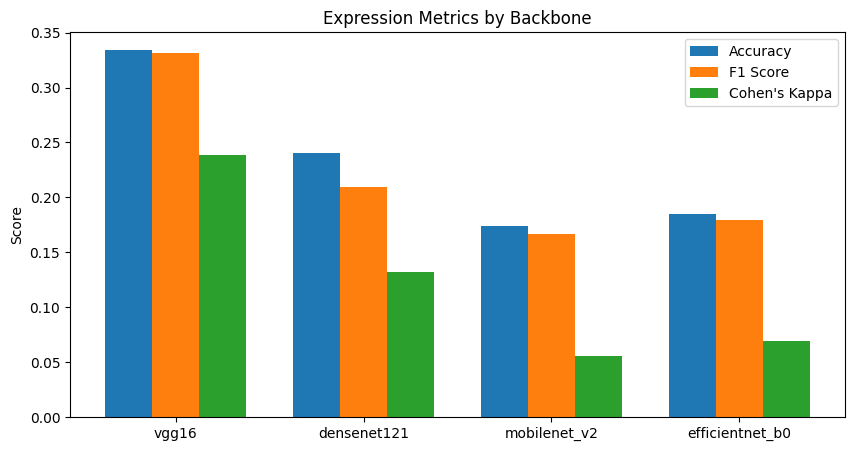

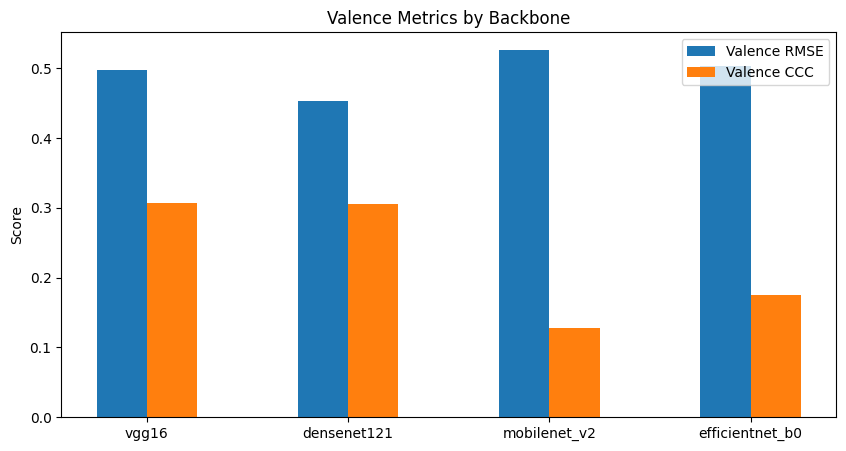

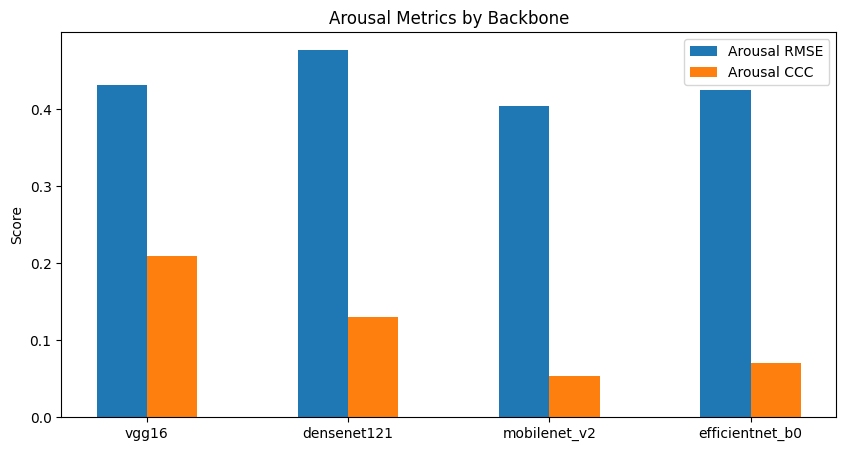

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# Use your existing dataset and model code
# Assuming: FacialExpressionDataset, FacialExpressionModel, val_loader

# ------------------------------
# Metrics functions
# ------------------------------
def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = 2 * covariance / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)
    return ccc

def sign_agreement(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def evaluate_model(model, data_loader, device):
    model.eval()
    all_exp, all_val, all_aro = [], [], []
    all_exp_pred, all_val_pred, all_aro_pred = [], [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long().cpu().numpy()
            val_labels = labels[:,1].cpu().numpy()
            aro_labels = labels[:,2].cpu().numpy()

            exp_logits, val_pred, aro_pred = model(imgs)
            exp_pred = exp_logits.argmax(1).cpu().numpy()
            val_pred = val_pred.squeeze(1).cpu().numpy()
            aro_pred = aro_pred.squeeze(1).cpu().numpy()

            all_exp.extend(exp_labels)
            all_val.extend(val_labels)
            all_aro.extend(aro_labels)
            all_exp_pred.extend(exp_pred)
            all_val_pred.extend(val_pred)
            all_aro_pred.extend(aro_pred)

    # Categorical metrics
    acc = accuracy_score(all_exp, all_exp_pred)
    f1 = f1_score(all_exp, all_exp_pred, average='weighted')
    kappa = cohen_kappa_score(all_exp, all_exp_pred)

    # Continuous metrics
    val_rmse = np.sqrt(np.mean((np.array(all_val) - np.array(all_val_pred))**2))
    val_corr, _ = pearsonr(all_val, all_val_pred)
    val_sagr = sign_agreement(all_val, all_val_pred)
    val_ccc = concordance_correlation_coefficient(all_val, all_val_pred)

    aro_rmse = np.sqrt(np.mean((np.array(all_aro) - np.array(all_aro_pred))**2))
    aro_corr, _ = pearsonr(all_aro, all_aro_pred)
    aro_sagr = sign_agreement(all_aro, all_aro_pred)
    aro_ccc = concordance_correlation_coefficient(all_aro, all_aro_pred)

    metrics = {
        'acc': acc, 'f1': f1, 'kappa': kappa,
        'val_rmse': val_rmse, 'val_corr': val_corr, 'val_sagr': val_sagr, 'val_ccc': val_ccc,
        'aro_rmse': aro_rmse, 'aro_corr': aro_corr, 'aro_sagr': aro_sagr, 'aro_ccc': aro_ccc
    }

    return metrics

# ------------------------------
# Run evaluation on all backbones
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbones = ['vgg16', 'densenet121', 'mobilenet_v2', 'efficientnet_b0']
all_metrics = {}

for backbone in backbones:
    print(f"\nEvaluating {backbone} backbone")
    model = FacialExpressionModel(backbone_name=backbone, num_classes=8, pretrained=False)
    model.load_state_dict(torch.load(f"{backbone}_trained.pth", map_location=device))
    model.to(device)
    metrics = evaluate_model(model, val_loader, device)
    all_metrics[backbone] = metrics
    print(metrics)

# ------------------------------
# Plot graphs
# ------------------------------
# Example: Accuracy, F1, Cohen's Kappa for expression
labels = list(all_metrics.keys())
acc = [all_metrics[b]['acc'] for b in labels]
f1 = [all_metrics[b]['f1'] for b in labels]
kappa = [all_metrics[b]['kappa'] for b in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, acc, width, label='Accuracy')
plt.bar(x, f1, width, label='F1 Score')
plt.bar(x + width, kappa, width, label="Cohen's Kappa")
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Expression Metrics by Backbone')
plt.legend()
plt.show()

# Example: Valence RMSE and CCC
val_rmse = [all_metrics[b]['val_rmse'] for b in labels]
val_ccc = [all_metrics[b]['val_ccc'] for b in labels]

plt.figure(figsize=(10,5))
plt.bar(x - width/2, val_rmse, width, label='Valence RMSE')
plt.bar(x + width/2, val_ccc, width, label='Valence CCC')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Valence Metrics by Backbone')
plt.legend()
plt.show()

# Example: Arousal RMSE and CCC
aro_rmse = [all_metrics[b]['aro_rmse'] for b in labels]
aro_ccc = [all_metrics[b]['aro_ccc'] for b in labels]

plt.figure(figsize=(10,5))
plt.bar(x - width/2, aro_rmse, width, label='Arousal RMSE')
plt.bar(x + width/2, aro_ccc, width, label='Arousal CCC')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Arousal Metrics by Backbone')
plt.legend()
plt.show()


Evaluating vgg16 backbone
{'acc': 0.33375, 'f1': 0.33155753166393487, 'kappa': 0.23816330176880474, 'val_rmse': 0.4980803, 'val_corr': 0.322959, 'val_sagr': 0.63125, 'val_ccc': 0.30621223251805424, 'aro_rmse': 0.43084136, 'aro_corr': 0.21851021, 'aro_sagr': 0.76, 'aro_ccc': 0.20882974072089042}

Evaluating densenet121 backbone
{'acc': 0.24, 'f1': 0.20977498740656245, 'kappa': 0.13192616375256327, 'val_rmse': 0.45328656, 'val_corr': 0.34440136, 'val_sagr': 0.69375, 'val_ccc': 0.30609843203974313, 'aro_rmse': 0.47569466, 'aro_corr': 0.2081727, 'aro_sagr': 0.77875, 'aro_ccc': 0.1297183567058368}

Evaluating mobilenet_v2 backbone
{'acc': 0.17375, 'f1': 0.16712923606594998, 'kappa': 0.055995801252126665, 'val_rmse': 0.5253922, 'val_corr': 0.13767931, 'val_sagr': 0.63875, 'val_ccc': 0.12825544865466523, 'aro_rmse': 0.40386495, 'aro_corr': 0.08160871, 'aro_sagr': 0.77, 'aro_ccc': 0.053931738338345914}

Evaluating efficientnet_b0 backbone
{'acc': 0.185, 'f1': 0.1790501248068111, 'kappa': 0.06

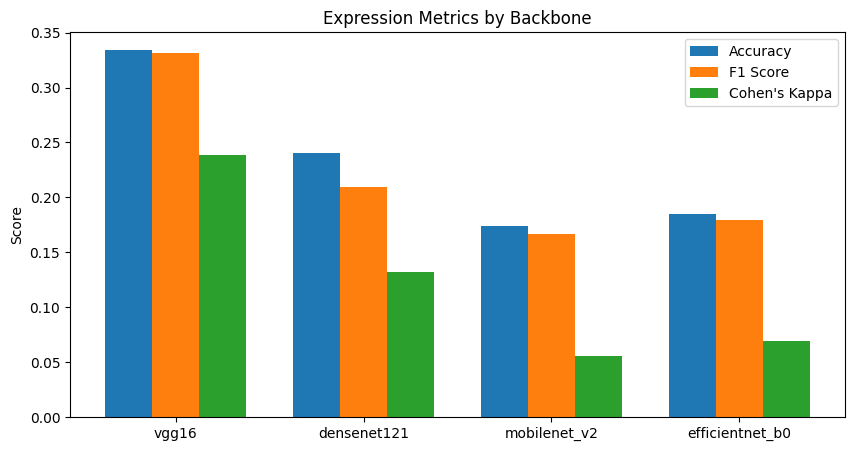

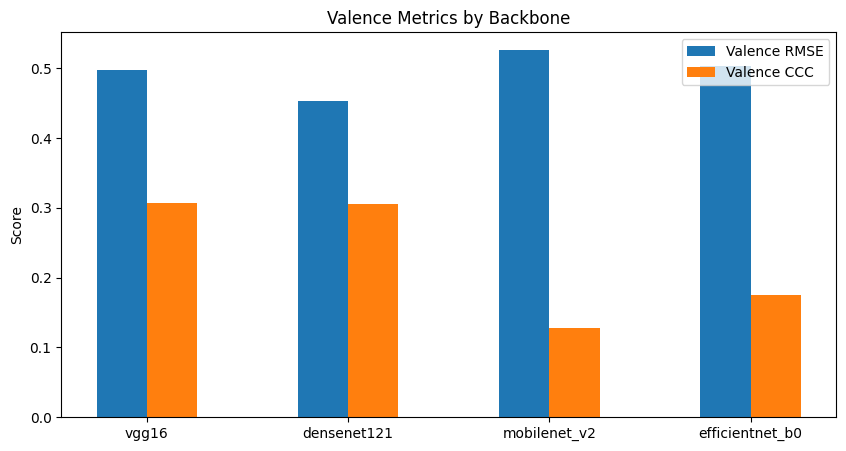

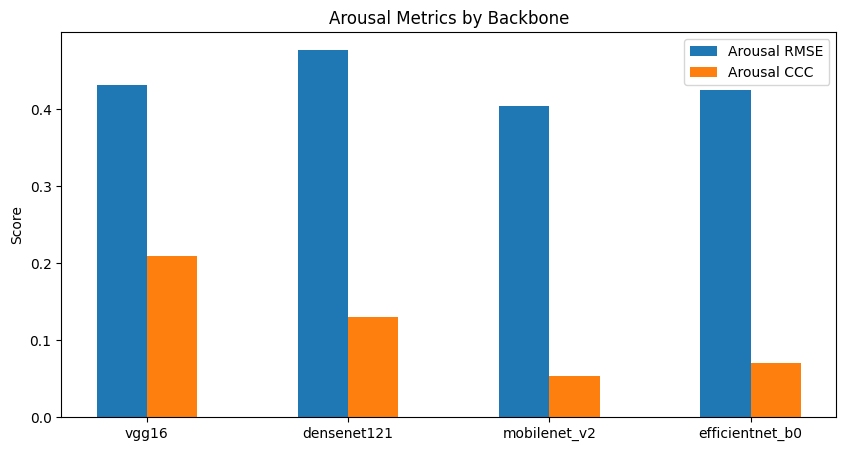

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Metrics helpers
# ------------------------------
def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.mean((y_true - mean_true)*(y_pred - mean_pred))
    ccc = 2*covariance / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)
    return ccc

def sign_agreement(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# ------------------------------
# Evaluation function
# ------------------------------
def evaluate_model(model, data_loader, device):
    model.eval()
    all_exp, all_val, all_aro = [], [], []
    all_exp_pred, all_val_pred, all_aro_pred = [], [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            exp_labels = labels[:,0].long().cpu().numpy()
            val_labels = labels[:,1].cpu().numpy()
            aro_labels = labels[:,2].cpu().numpy()

            exp_logits, val_pred, aro_pred = model(imgs)
            exp_pred = exp_logits.argmax(1).cpu().numpy()
            val_pred = val_pred.squeeze(1).cpu().numpy()
            aro_pred = aro_pred.squeeze(1).cpu().numpy()

            all_exp.extend(exp_labels)
            all_val.extend(val_labels)
            all_aro.extend(aro_labels)
            all_exp_pred.extend(exp_pred)
            all_val_pred.extend(val_pred)
            all_aro_pred.extend(aro_pred)

    # Categorical metrics
    acc = accuracy_score(all_exp, all_exp_pred)
    f1 = f1_score(all_exp, all_exp_pred, average='weighted')
    kappa = cohen_kappa_score(all_exp, all_exp_pred)

    # Continuous metrics
    val_rmse = np.sqrt(np.mean((np.array(all_val) - np.array(all_val_pred))**2))
    val_corr, _ = pearsonr(all_val, all_val_pred)
    val_sagr = sign_agreement(all_val, all_val_pred)
    val_ccc = concordance_correlation_coefficient(all_val, all_val_pred)

    aro_rmse = np.sqrt(np.mean((np.array(all_aro) - np.array(all_aro_pred))**2))
    aro_corr, _ = pearsonr(all_aro, all_aro_pred)
    aro_sagr = sign_agreement(all_aro, all_aro_pred)
    aro_ccc = concordance_correlation_coefficient(all_aro, all_aro_pred)

    metrics = {
        'acc': acc, 'f1': f1, 'kappa': kappa,
        'val_rmse': val_rmse, 'val_corr': val_corr, 'val_sagr': val_sagr, 'val_ccc': val_ccc,
        'aro_rmse': aro_rmse, 'aro_corr': aro_corr, 'aro_sagr': aro_sagr, 'aro_ccc': aro_ccc
    }
    return metrics

# ------------------------------
# Run evaluation on all backbones
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbones = ['vgg16', 'densenet121', 'mobilenet_v2', 'efficientnet_b0']  # Add 'resnet18' if needed
all_metrics = {}

for backbone in backbones:
    print(f"\nEvaluating {backbone} backbone")
    model = FacialExpressionModel(backbone_name=backbone, num_classes=8, pretrained=False)
    model.load_state_dict(torch.load(f"{backbone}_trained.pth", map_location=device))
    model.to(device)
    metrics = evaluate_model(model, val_loader, device)
    all_metrics[backbone] = metrics
    print(metrics)

# ------------------------------
# Plotting metrics
# ------------------------------
labels = list(all_metrics.keys())
x = np.arange(len(labels))
width = 0.25

# Expression: Accuracy, F1, Cohen's Kappa
acc = [all_metrics[b]['acc'] for b in labels]
f1 = [all_metrics[b]['f1'] for b in labels]
kappa = [all_metrics[b]['kappa'] for b in labels]

plt.figure(figsize=(10,5))
plt.bar(x - width, acc, width, label='Accuracy')
plt.bar(x, f1, width, label='F1 Score')
plt.bar(x + width, kappa, width, label="Cohen's Kappa")
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Expression Metrics by Backbone')
plt.legend()
plt.show()

# Valence: RMSE and CCC
val_rmse = [all_metrics[b]['val_rmse'] for b in labels]
val_ccc = [all_metrics[b]['val_ccc'] for b in labels]

plt.figure(figsize=(10,5))
plt.bar(x - width/2, val_rmse, width, label='Valence RMSE')
plt.bar(x + width/2, val_ccc, width, label='Valence CCC')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Valence Metrics by Backbone')
plt.legend()
plt.show()

# Arousal: RMSE and CCC
aro_rmse = [all_metrics[b]['aro_rmse'] for b in labels]
aro_ccc = [all_metrics[b]['aro_ccc'] for b in labels]

plt.figure(figsize=(10,5))
plt.bar(x - width/2, aro_rmse, width, label='Arousal RMSE')
plt.bar(x + width/2, aro_ccc, width, label='Arousal CCC')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Arousal Metrics by Backbone')
plt.legend()
plt.show()

In [10]:
backbone_info = {
    'vgg16': {
        'architecture': 'VGG16 with 13 conv layers + 3 FC layers',
        'parameters': '≈138M',
        'batch_size': 32,
        'learning_rate': 1e-4,
        'optimizer': 'Adam',
        'pretrained': False,
        'transfer_learning': 'Not used, trained from scratch'
    },
    'densenet121': {
        'architecture': 'DenseNet-121 with dense blocks',
        'parameters': '≈8M',
        'batch_size': 32,
        'learning_rate': 1e-4,
        'optimizer': 'Adam',
        'pretrained': False,
        'transfer_learning': 'Not used, trained from scratch'
    },
    'mobilenet_v2': {
        'architecture': 'MobileNet V2 with inverted residuals',
        'parameters': '≈3.4M',
        'batch_size': 32,
        'learning_rate': 1e-4,
        'optimizer': 'Adam',
        'pretrained': False,
        'transfer_learning': 'Not used, trained from scratch'
    },
    'efficientnet_b0': {
        'architecture': 'EfficientNet B0 compound scaled',
        'parameters': '≈5.3M',
        'batch_size': 32,
        'learning_rate': 1e-4,
        'optimizer': 'Adam',
        'pretrained': False,
        'transfer_learning': 'Not used, trained from scratch'
    }
}

for b, info in backbone_info.items():
    print(f"{b.upper()} info:")
    for k, v in info.items():
        print(f"  {k}: {v}")
    print()

VGG16 info:
  architecture: VGG16 with 13 conv layers + 3 FC layers
  parameters: ≈138M
  batch_size: 32
  learning_rate: 0.0001
  optimizer: Adam
  pretrained: False
  transfer_learning: Not used, trained from scratch

DENSENET121 info:
  architecture: DenseNet-121 with dense blocks
  parameters: ≈8M
  batch_size: 32
  learning_rate: 0.0001
  optimizer: Adam
  pretrained: False
  transfer_learning: Not used, trained from scratch

MOBILENET_V2 info:
  architecture: MobileNet V2 with inverted residuals
  parameters: ≈3.4M
  batch_size: 32
  learning_rate: 0.0001
  optimizer: Adam
  pretrained: False
  transfer_learning: Not used, trained from scratch

EFFICIENTNET_B0 info:
  architecture: EfficientNet B0 compound scaled
  parameters: ≈5.3M
  batch_size: 32
  learning_rate: 0.0001
  optimizer: Adam
  pretrained: False
  transfer_learning: Not used, trained from scratch



## Sample Predictions
- Displaying correctly and incorrectly classified images with predicted vs. ground-truth labels.

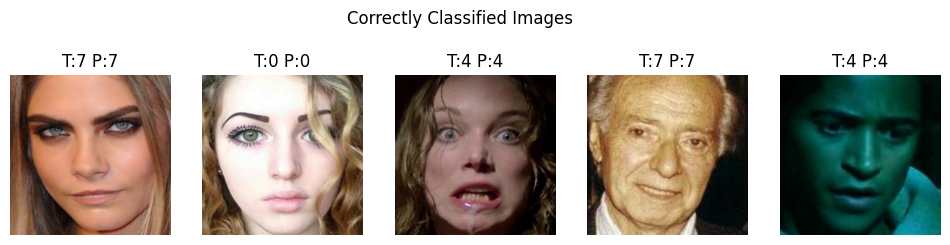

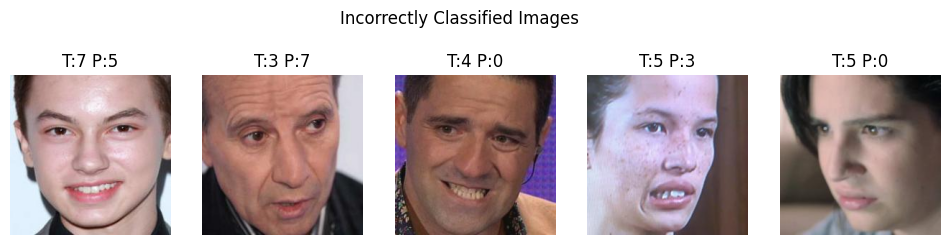

In [11]:
import matplotlib.pyplot as plt

def show_examples(model, data_loader, device, num_examples=5):
    model.eval()
    correct_imgs, correct_labels, correct_preds = [], [], []
    incorrect_imgs, incorrect_labels, incorrect_preds = [], [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            exp_labels = labels[:,0].long().to(device)
            exp_logits, _, _ = model(imgs)
            exp_preds = exp_logits.argmax(1)

            for i in range(len(imgs)):
                img = imgs[i].cpu().permute(1,2,0).numpy()
                true = exp_labels[i].item()
                pred = exp_preds[i].item()
                if true == pred and len(correct_imgs) < num_examples:
                    correct_imgs.append(img)
                    correct_labels.append(true)
                    correct_preds.append(pred)
                elif true != pred and len(incorrect_imgs) < num_examples:
                    incorrect_imgs.append(img)
                    incorrect_labels.append(true)
                    incorrect_preds.append(pred)

            if len(correct_imgs) >= num_examples and len(incorrect_imgs) >= num_examples:
                break

    # Plot correct
    plt.figure(figsize=(12,3))
    for i, img in enumerate(correct_imgs):
        plt.subplot(1,num_examples,i+1)
        plt.imshow(img)
        plt.title(f"T:{correct_labels[i]} P:{correct_preds[i]}")
        plt.axis('off')
    plt.suptitle("Correctly Classified Images")
    plt.show()

    # Plot incorrect
    plt.figure(figsize=(12,3))
    for i, img in enumerate(incorrect_imgs):
        plt.subplot(1,num_examples,i+1)
        plt.imshow(img)
        plt.title(f"T:{incorrect_labels[i]} P:{incorrect_preds[i]}")
        plt.axis('off')
    plt.suptitle("Incorrectly Classified Images")
    plt.show()

# Example usage:
show_examples(model, val_loader, device, num_examples=5)

## Training Graphs
- Plotting loss curves and accuracy trends over epochs to visualize model performance.


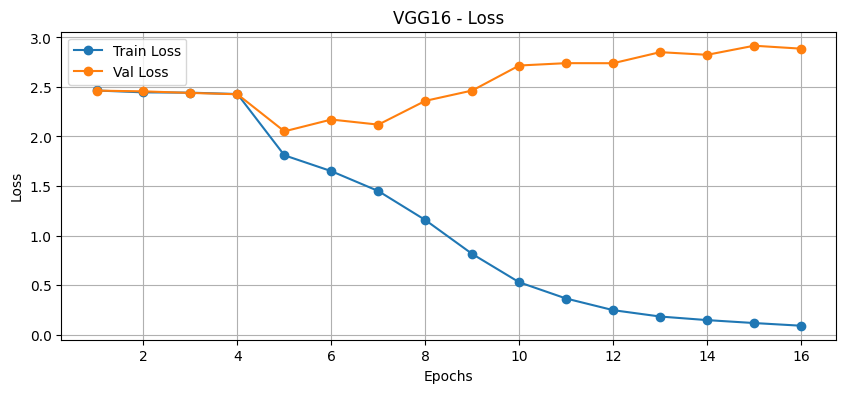

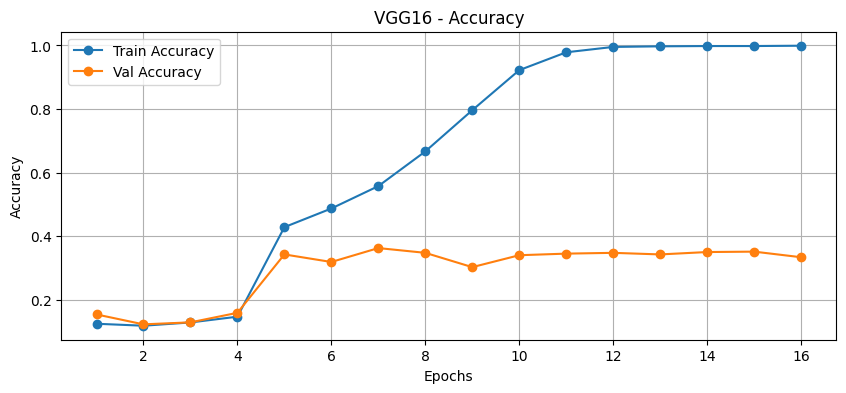

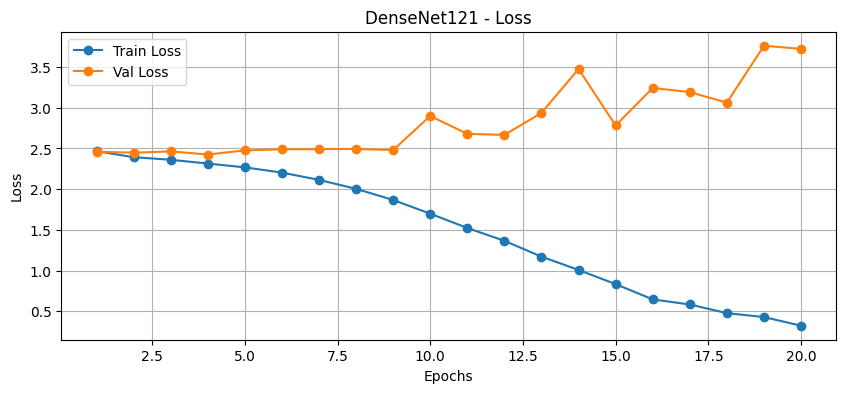

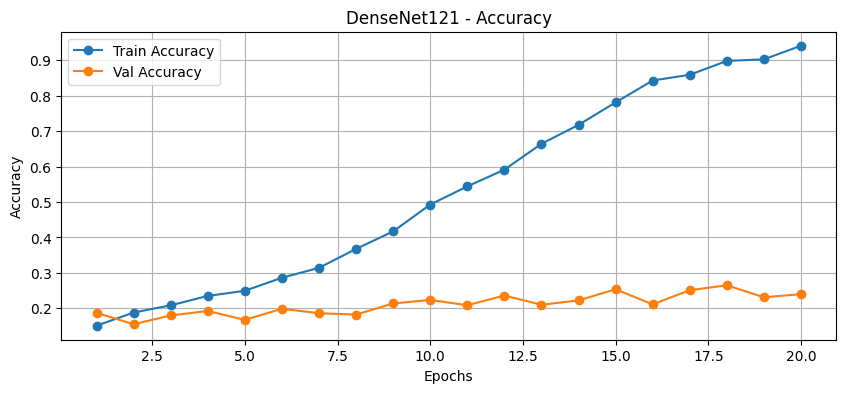

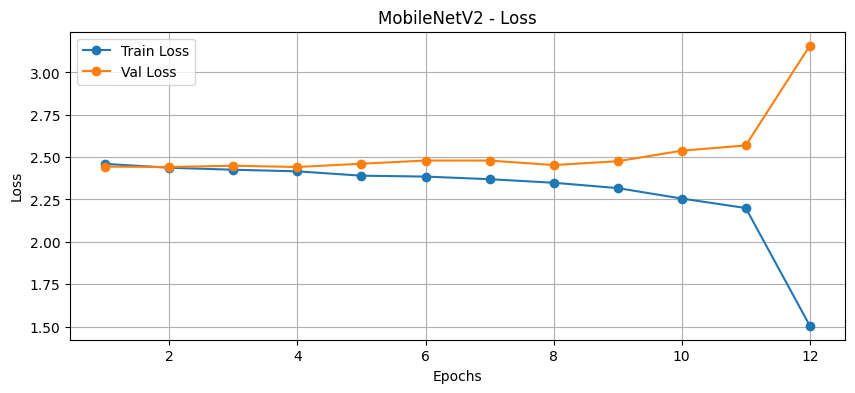

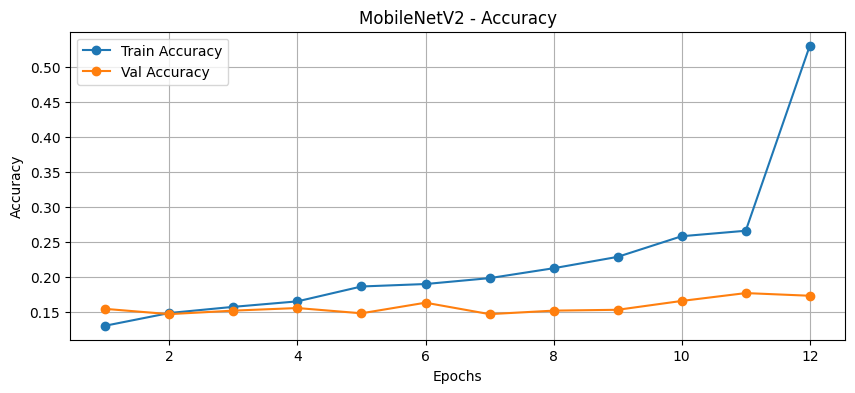

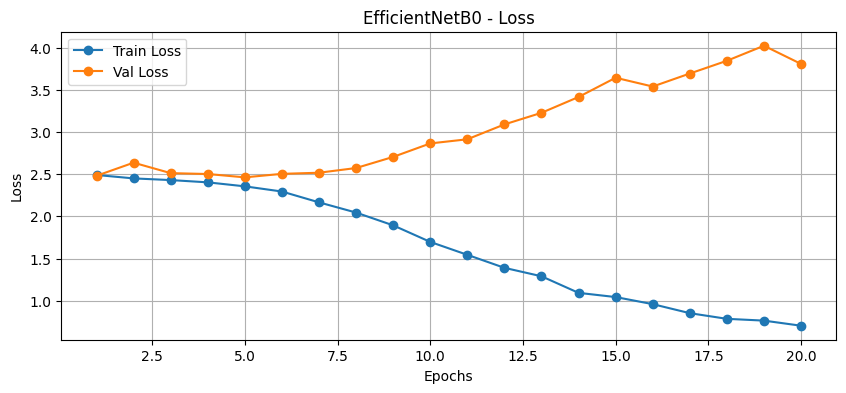

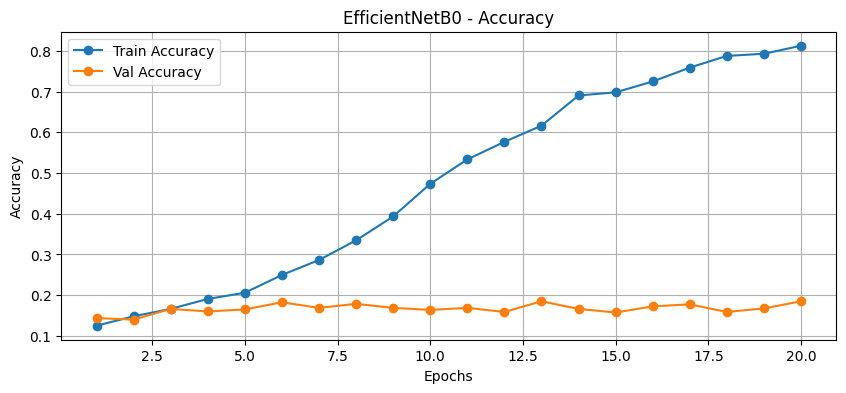

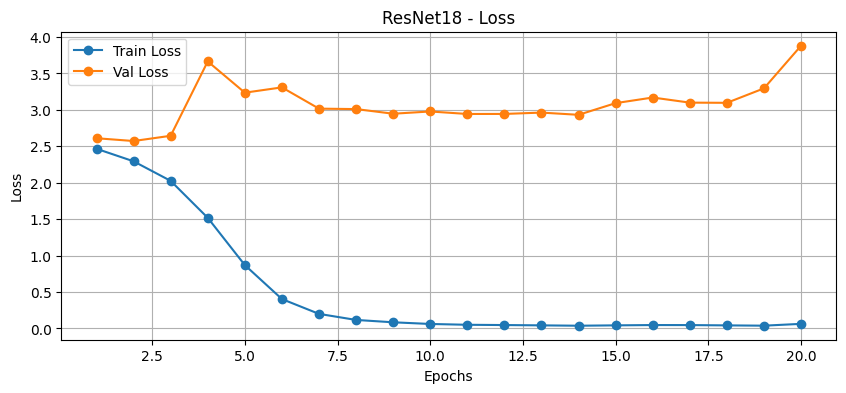

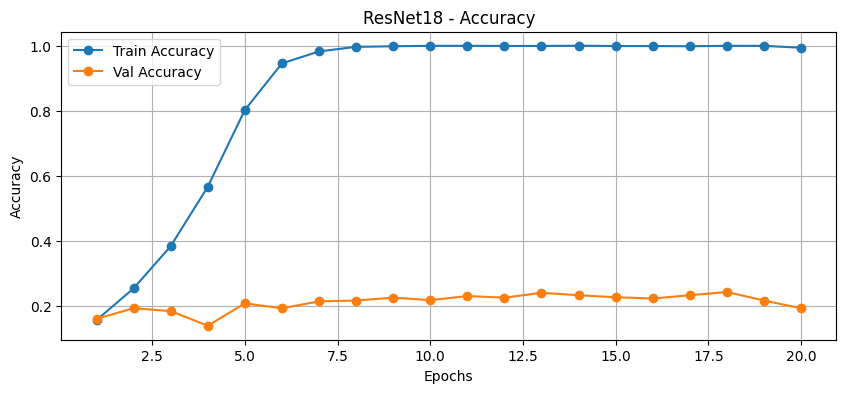

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# Training logs
# ------------------------------

# VGG16
train_loss_vgg16 = [2.4641,2.4453,2.4422,2.4284,1.8100,1.6496,1.4491,1.1565,0.8136,0.5279,0.3638,0.2465,0.1822,0.1461,0.1165,0.0894]
val_loss_vgg16 = [2.4628,2.4553,2.4396,2.4261,2.0518,2.1709,2.1195,2.3594,2.4639,2.7163,2.7402,2.7395,2.8511,2.8243,2.9161,2.8865]
train_acc_vgg16 = [0.1244,0.1182,0.1285,0.1466,0.4283,0.4870,0.5574,0.6665,0.7962,0.9222,0.9784,0.9953,0.9972,0.9981,0.9981,0.9991]
val_acc_vgg16 = [0.1537,0.1225,0.1288,0.1588,0.3425,0.3187,0.3625,0.3475,0.3025,0.3400,0.3450,0.3475,0.3425,0.3500,0.3513,0.3337]

# DenseNet121
train_loss_densenet = [2.4674,2.3933,2.3614,2.3152,2.2680,2.2038,2.1145,2.0039,1.8675,1.6988,1.5231,1.3651,1.1707,1.0069,0.8331,0.6450,0.5829,0.4764,0.4282,0.3218]
val_loss_densenet = [2.4610,2.4480,2.4647,2.4262,2.4764,2.4905,2.4921,2.4949,2.4810,2.9001,2.6798,2.6668,2.9373,3.4769,2.7830,3.2443,3.1934,3.0637,3.7632,3.7242]
train_acc_densenet = [0.1510,0.1882,0.2085,0.2351,0.2495,0.2863,0.3142,0.3676,0.4170,0.4927,0.5439,0.5911,0.6640,0.7174,0.7809,0.8425,0.8587,0.8978,0.9022,0.9406]
val_acc_densenet = [0.1875,0.1550,0.1800,0.1925,0.1675,0.1988,0.1862,0.1825,0.2137,0.2238,0.2087,0.2362,0.2100,0.2225,0.2537,0.2112,0.2512,0.2650,0.2313,0.2400]

# MobileNetV2
train_loss_mobilenet = [2.4602,2.4374,2.4257,2.4161,2.3905,2.3852,2.3698,2.3488,2.3173,2.2555,2.1997,1.5047]
val_loss_mobilenet = [2.4440,2.4418,2.4494,2.4417,2.4612,2.4800,2.4798,2.4533,2.4756,2.5381,2.5690,3.1578]
train_acc_mobilenet = [0.1310,0.1491,0.1579,0.1657,0.1869,0.1904,0.1988,0.2129,0.2291,0.2585,0.2663,0.5299]
val_acc_mobilenet = [0.1550,0.1475,0.1525,0.1562,0.1487,0.1638,0.1475,0.1525,0.1537,0.1663,0.1775,0.1737]

# EfficientNetB0
train_loss_efficient = [2.4912,2.4506,2.4307,2.4037,2.3564,2.2949,2.1664,2.0452,1.8937,1.6971,1.5440,1.3897,1.2895,1.0928,1.0429,0.9589,0.8518,0.7847,0.7634,0.7029]
val_loss_efficient = [2.4817,2.6370,2.5130,2.5026,2.4630,2.5045,2.5178,2.5736,2.7055,2.8654,2.9146,3.0909,3.2286,3.4164,3.6446,3.5403,3.6947,3.8459,4.0245,3.8085]
train_acc_efficient = [0.1250,0.1482,0.1663,0.1907,0.2060,0.2495,0.2863,0.3345,0.3932,0.4733,0.5333,0.5764,0.6161,0.6902,0.6980,0.7246,0.7587,0.7874,0.7927,0.8124]
val_acc_efficient = [0.1437,0.1400,0.1663,0.1600,0.1650,0.1825,0.1688,0.1787,0.1688,0.1638,0.1688,0.1588,0.1850,0.1663,0.1575,0.1725,0.1775,0.1588,0.1675,0.1850]

# ResNet18
train_loss_resnet18 = [2.4663,2.2941,2.0256,1.5183,0.8693,0.4030,0.1994,0.1163,0.0840,0.0610,0.0498,0.0461,0.0418,0.0369,0.0419,0.0461,0.0456,0.0416,0.0375,0.0625]
val_loss_resnet18 = [2.6110,2.5727,2.6445,3.6654,3.2364,3.3092,3.0171,3.0113,2.9475,2.9783,2.9441,2.9446,2.9630,2.9325,3.0929,3.1700,3.0998,3.0972,3.2958,3.8811]
train_acc_resnet18 = [0.1560,0.2535,0.3832,0.5658,0.8018,0.9450,0.9819,0.9959,0.9978,0.9991,0.9991,0.9987,0.9987,0.9994,0.9984,0.9984,0.9978,0.9991,0.9991,0.9931]
val_acc_resnet18 = [0.1600,0.1925,0.1837,0.1388,0.2075,0.1925,0.2137,0.2162,0.2250,0.2175,0.2300,0.2250,0.2400,0.2325,0.2263,0.2225,0.2325,0.2425,0.2162,0.1925]

# ------------------------------
# Function to plot
# ------------------------------
def plot_training_graphs(train_loss, val_loss, train_acc, val_acc, backbone_name):
    epochs_loss = np.arange(1, len(train_loss)+1)
    epochs_acc = np.arange(1, len(train_acc)+1)
    
    plt.figure(figsize=(10,4))
    plt.plot(epochs_loss, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs_loss, val_loss, label='Val Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{backbone_name} - Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(10,4))
    plt.plot(epochs_acc, train_acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_acc, val_acc, label='Val Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{backbone_name} - Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# ------------------------------
# Plot for all backbones
# ------------------------------
plot_training_graphs(train_loss_vgg16, val_loss_vgg16, train_acc_vgg16, val_acc_vgg16, 'VGG16')
plot_training_graphs(train_loss_densenet, val_loss_densenet, train_acc_densenet, val_acc_densenet, 'DenseNet121')
plot_training_graphs(train_loss_mobilenet, val_loss_mobilenet, train_acc_mobilenet, val_acc_mobilenet, 'MobileNetV2')
plot_training_graphs(train_loss_efficient, val_loss_efficient, train_acc_efficient, val_acc_efficient, 'EfficientNetB0')
plot_training_graphs(train_loss_resnet18, val_loss_resnet18, train_acc_resnet18, val_acc_resnet18, 'ResNet18')

## Custom CNN Model
- Definition of a custom convolutional neural network designed for emotion recognition.


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# ---------------------------
# 1. Custom CNN Definition
# ---------------------------
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.shared_fc = nn.Sequential(
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Separate heads for multi-task outputs
        self.exp_head = nn.Linear(256, num_classes)  # Expression
        self.val_head = nn.Linear(256, 1)           # Valence
        self.aro_head = nn.Linear(256, 1)           # Arousal

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.shared_fc(x)
        exp_out = self.exp_head(x)
        val_out = self.val_head(x)
        aro_out = self.aro_head(x)
        return exp_out, val_out, aro_out

# ---------------------------
# 2. Training Loop
# ---------------------------
def train_custom_cnn(model, train_loader, val_loader, device, epochs=20, lr=1e-4):
    model.to(device)
    
    # Loss functions
    criterion_exp = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []
    
    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            exp_labels = labels[:,0].long().to(device)
            val_labels = labels[:,1].float().unsqueeze(1).to(device)
            aro_labels = labels[:,2].float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            exp_out, val_out, aro_out = model(images)
            
            loss_exp = criterion_exp(exp_out, exp_labels)
            loss_val = criterion_reg(val_out, val_labels)
            loss_aro = criterion_reg(aro_out, aro_labels)
            
            # Combine losses (you can weight them if needed)
            loss = loss_exp + loss_val + loss_aro
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = exp_out.max(1)
            correct += (predicted == exp_labels).sum().item()
            total += images.size(0)
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                exp_labels = labels[:,0].long().to(device)
                val_labels = labels[:,1].float().unsqueeze(1).to(device)
                aro_labels = labels[:,2].float().unsqueeze(1).to(device)
                
                exp_out, val_out, aro_out = model(images)
                
                loss_exp = criterion_exp(exp_out, exp_labels)
                loss_val = criterion_reg(val_out, val_labels)
                loss_aro = criterion_reg(aro_out, aro_labels)
                
                loss = loss_exp + loss_val + loss_aro
                val_loss += loss.item() * images.size(0)
                
                _, predicted = exp_out.max(1)
                correct += (predicted == exp_labels).sum().item()
                total += images.size(0)
        
        val_loss /= total
        val_acc = correct / total
        
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        
        print(f"Epoch {epoch}/{epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    
    return train_loss_list, val_loss_list, train_acc_list, val_acc_list

model = CustomCNN(num_classes=8)
train_loss_list, val_loss_list, train_acc_list, val_acc_list = train_custom_cnn(model, train_loader, val_loader, device, epochs=20, lr=1e-4)


Epoch 1/20: Train Loss=2.4778, Train Acc=0.1529, Val Loss=2.4119, Val Acc=0.1875
Epoch 2/20: Train Loss=2.3784, Train Acc=0.2107, Val Loss=2.4027, Val Acc=0.2075
Epoch 3/20: Train Loss=2.3305, Train Acc=0.2332, Val Loss=2.4063, Val Acc=0.2087
Epoch 4/20: Train Loss=2.2889, Train Acc=0.2629, Val Loss=2.3930, Val Acc=0.2150
Epoch 5/20: Train Loss=2.2509, Train Acc=0.2666, Val Loss=2.3770, Val Acc=0.2137
Epoch 6/20: Train Loss=2.2073, Train Acc=0.3023, Val Loss=2.3682, Val Acc=0.2362
Epoch 7/20: Train Loss=2.1627, Train Acc=0.3214, Val Loss=2.3568, Val Acc=0.2112
Epoch 8/20: Train Loss=2.1207, Train Acc=0.3385, Val Loss=2.3441, Val Acc=0.2288
Epoch 9/20: Train Loss=2.0635, Train Acc=0.3535, Val Loss=2.3134, Val Acc=0.2437
Epoch 10/20: Train Loss=2.0177, Train Acc=0.3717, Val Loss=2.3199, Val Acc=0.2512
Epoch 11/20: Train Loss=1.9601, Train Acc=0.3954, Val Loss=2.3025, Val Acc=0.2375
Epoch 12/20: Train Loss=1.9191, Train Acc=0.4139, Val Loss=2.2926, Val Acc=0.2500
Epoch 13/20: Train Loss=1

## Training Graphs For Custom CNN
- Plotting loss curves and accuracy trends over epochs to visualize model performance.


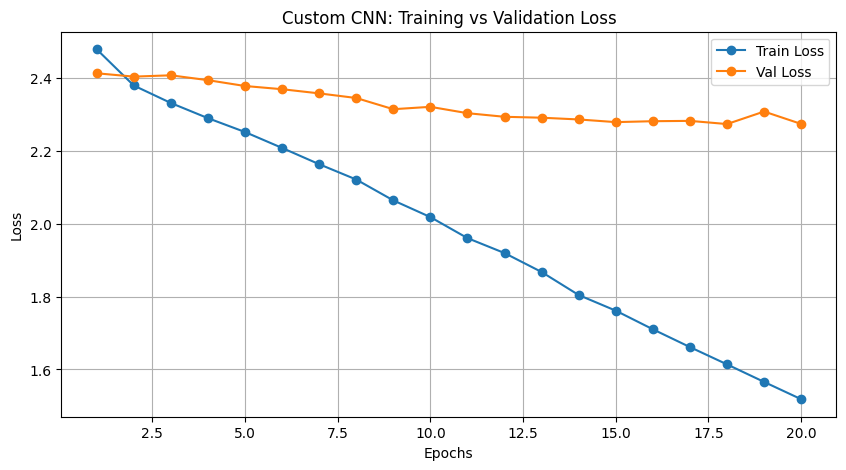

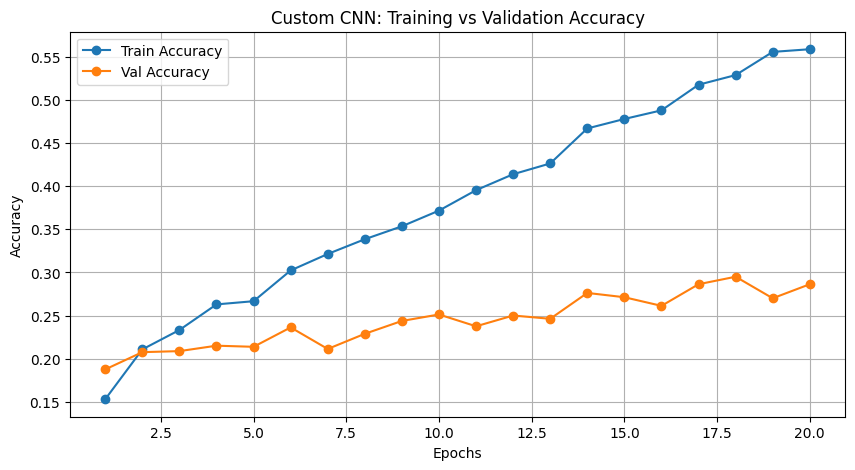

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Custom CNN data from your logs
train_loss_list = [2.4778, 2.3784, 2.3305, 2.2889, 2.2509, 2.2073, 2.1627, 2.1207, 2.0635, 2.0177,
                   1.9601, 1.9191, 1.8672, 1.8041, 1.7612, 1.7102, 1.6614, 1.6140, 1.5659, 1.5185]
val_loss_list   = [2.4119, 2.4027, 2.4063, 2.3930, 2.3770, 2.3682, 2.3568, 2.3441, 2.3134, 2.3199,
                   2.3025, 2.2926, 2.2901, 2.2853, 2.2780, 2.2805, 2.2814, 2.2727, 2.3070, 2.2730]

train_acc_list = [0.1529, 0.2107, 0.2332, 0.2629, 0.2666, 0.3023, 0.3214, 0.3385, 0.3535, 0.3717,
                  0.3954, 0.4139, 0.4264, 0.4670, 0.4780, 0.4880, 0.5177, 0.5289, 0.5558, 0.5589]
val_acc_list   = [0.1875, 0.2075, 0.2087, 0.2150, 0.2137, 0.2362, 0.2112, 0.2288, 0.2437, 0.2512,
                  0.2375, 0.2500, 0.2462, 0.2762, 0.2712, 0.2612, 0.2863, 0.2950, 0.2700, 0.2863]

epochs = np.arange(1, 21)

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss_list, marker='o', label='Train Loss')
plt.plot(epochs, val_loss_list, marker='o', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Custom CNN: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc_list, marker='o', label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Custom CNN: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()